In [ ]:
!pip uninstall numpy

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Would remove:
    /usr/local/bin/f2py
    /usr/local/bin/numpy-config
    /usr/local/lib/python3.11/dist-packages/numpy-2.0.2.dist-info/*
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libgfortran-040039e1-0352e75f.so.5.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libquadmath-96973f99-934c22de.so.0.0.0
    /usr/local/lib/python3.11/dist-packages/numpy.libs/libscipy_openblas64_-99b71e71.so
    /usr/local/lib/python3.11/dist-packages/numpy/*
Proceed (Y/n)? y
  Successfully uninstalled numpy-2.0.2


In [ ]:
!pip uninstall numpy -y

In [ ]:
!pip install numpy==1.23.5

In [ ]:
!pip uninstall pmdarima

Found existing installation: pmdarima 2.0.4
Uninstalling pmdarima-2.0.4:
  Would remove:
    /usr/local/lib/python3.11/dist-packages/pmdarima-2.0.4.dist-info/*
    /usr/local/lib/python3.11/dist-packages/pmdarima/*
Proceed (Y/n)? y
  Successfully uninstalled pmdarima-2.0.4


In [ ]:
!pip install pmdarima

  Using cached pmdarima-2.0.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl.metadata (7.8 kB)
Using cached pmdarima-2.0.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.manylinux_2_28_x86_64.whl (2.2 MB)


In [ ]:
import pmdarima as pm

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
from tqdm import tqdm_notebook
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from itertools import product
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 7.5]
# read in data file
df = pd.read_csv('/content/AMZN.csv', index_col='Date', parse_dates=True)
#df['date'] = pd.to_datetime(df['date'])
#df.set_index('date', inplace=True)
df.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-02-20,72.324501,74.438499,72.324501,73.417503,73.417503,129984000
2018-02-21,74.250000,75.174500,73.945999,74.146004,74.146004,126088000
2018-02-22,74.767998,75.126999,73.788002,74.266998,74.266998,97162000
2018-02-23,74.766998,75.000000,74.324997,75.000000,75.000000,88362000
2018-02-26,75.459999,76.141998,75.349998,76.097504,76.097504,99100000


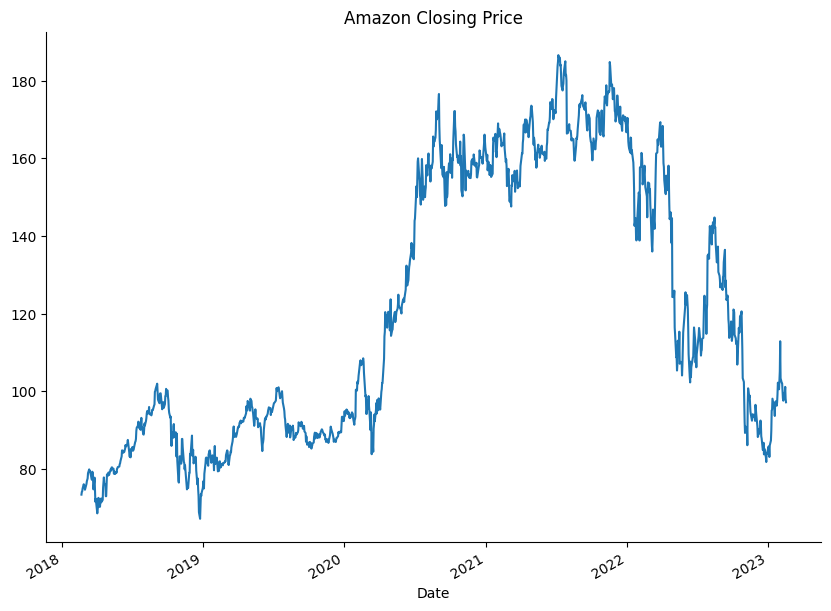

In [ ]:
# @title data

from matplotlib import pyplot as plt
df['Close'].plot(kind='line', title='Amazon Closing Price')
plt.gca().spines[['top', 'right']].set_visible(False)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1259 entries, 2018-02-20 to 2023-02-17
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Open       1259 non-null   float64
 1   High       1259 non-null   float64
 2   Low        1259 non-null   float64
 3   Close      1259 non-null   float64
 4   Adj Close  1259 non-null   float64
 5   Volume     1259 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 68.9 KB


Test for Non-Stationarity

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Close'].dropna())
print('p-vlaue: ', result[1])

result = adfuller(df['Close'].diff().dropna())
print('p-vlaue: ', result[1])



p-vlaue:  0.45297105465166737
p-vlaue:  0.0


In [ ]:
# ADF test on original series
result = adfuller(df['Close'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -1.6578089913331728
p-value: 0.45297105465166737
Critical Values: {'1%': -3.4355588184378574, '5%': -2.8638402312881497, '10%': -2.5679946684494275}


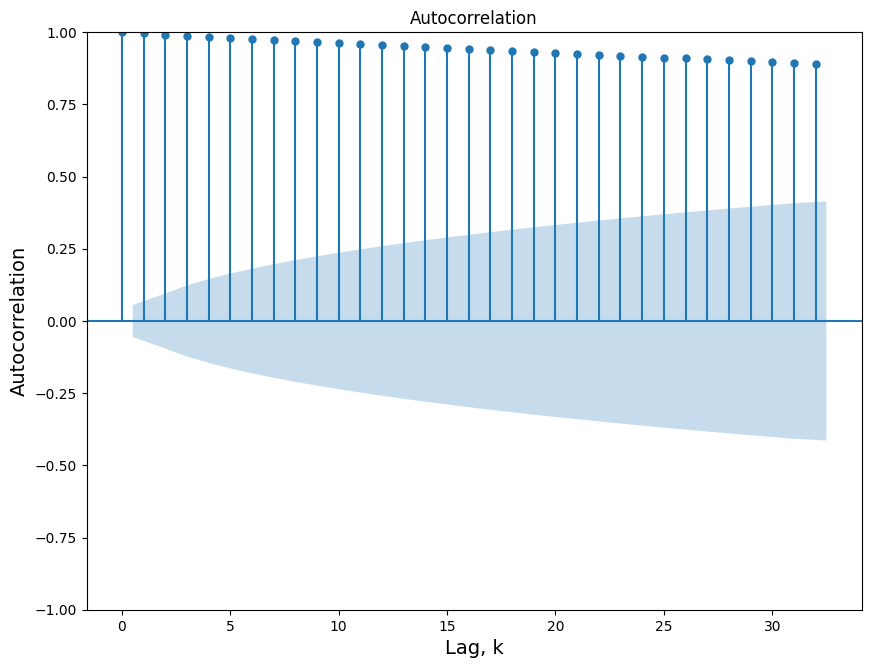

In [ ]:
#plot the autocorrelation function ACF

# Plot ACF
plot_acf(df['Close'])
plt.xlabel('Lag, k', fontsize=14)
plt.ylabel('Autocorrelation', fontsize=14)
plt.show()

In [ ]:
diff_data = df['Close'].diff().dropna()

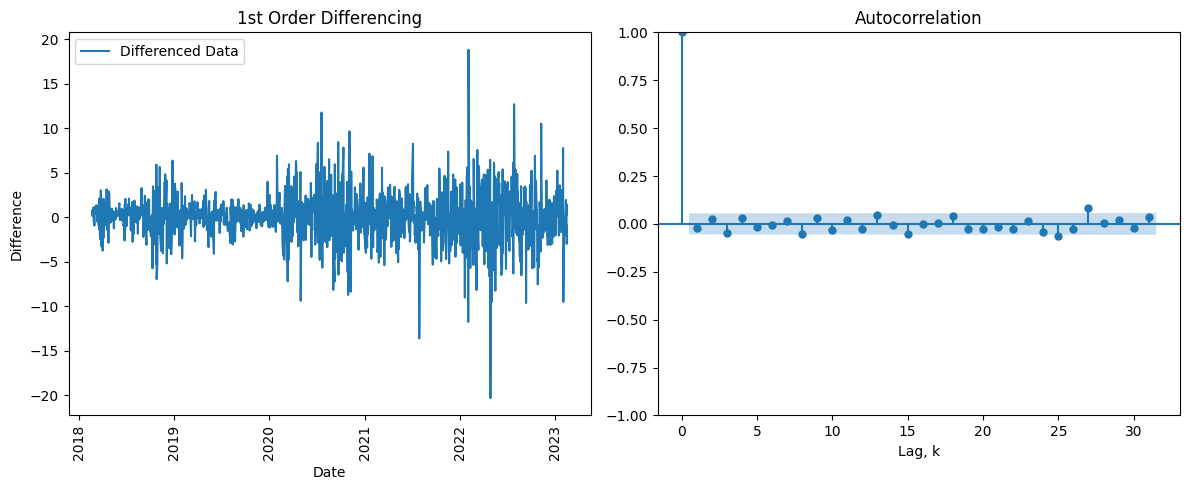

ADF Statistic (Differenced): -36.25077933242776
p-value (Differenced): 0.0
Critical Values (Differenced): {'1%': -3.4355629707955395, '5%': -2.863842063387667, '10%': -2.567995644141416}


In [ ]:
# Create figure with two subplots
f = plt.figure(figsize=(12, 5))  # Adjusted figure size for clarity

# Left subplot: 1st order differencing
ax1 = f.add_subplot(121)
ax1.set_title('1st Order Differencing')
ax1.plot( diff_data, label='Differenced Data')  # Use 'date' for x-axis
ax1.set_xlabel('Date')
ax1.set_ylabel('Difference')
ax1.tick_params(axis='x', rotation=90)  # Rotate x-axis labels
ax1.legend()

# Right subplot: ACF of differenced series
ax2 = f.add_subplot(122)
ax2.set_title('ACF of Differenced Series')
plot_acf(diff_data, ax=ax2)
ax2.set_xlabel('Lag, k')

# Adjust layout and display
plt.tight_layout()
plt.show()

# ADF test on differenced series
result_diff = adfuller(diff_data)
print('ADF Statistic (Differenced):', result_diff[0])
print('p-value (Differenced):', result_diff[1])
print('Critical Values (Differenced):', result_diff[4])


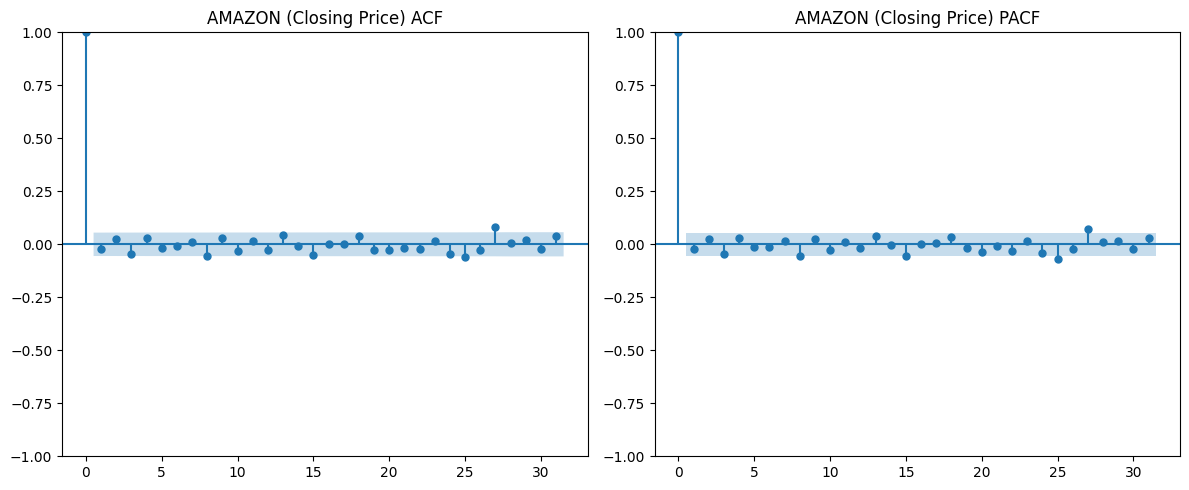

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF and PACF of differenced series
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
plot_acf(diff_data, ax=ax1, title='AMAZON (Closing Price) ACF')
plot_pacf(diff_data, ax=ax2, title='AMAZON (Closing Price) PACF')
plt.tight_layout()
plt.show()

In [ ]:
# ARIMA Model Selection (p=3, d=1, q=3)
lowest_aic = float("inf")
best_order = None
best_model = None
for p in range(4):
    for q in range(4):
        try:
            model = ARIMA(df['Close'], order=(p, 1, q)).fit()
            if model.aic < lowest_aic:
                best_order = (p, 1, q)
                best_model = model
                lowest_aic = model.aic
        except:
            pass

print("Best ARIMA Order:", best_order)

Best ARIMA Order: (2, 1, 2)


**Test model performance**

Best ARIMA Order: (2, 1, 2)
Model Performance:
Mean Absolute Error (MAE):      1.9761
Mean Squared Error (MSE):       11.8179
Root Mean Squared Error (RMSE): 3.4377
R-squared (R² Score):           0.9902


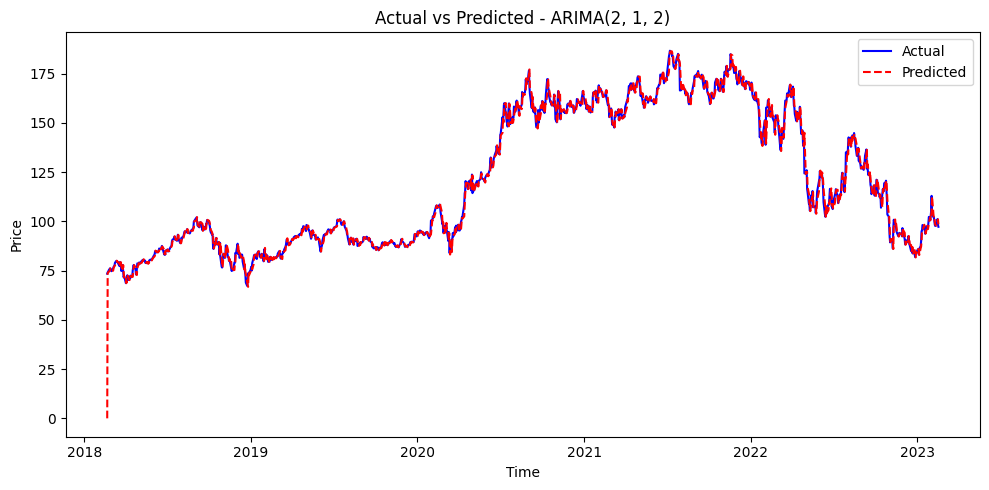

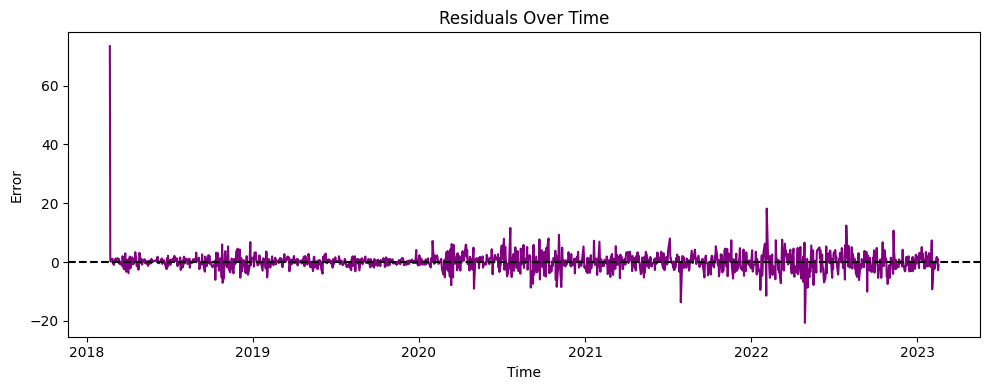

In [ ]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# ARIMA model selection
lowest_aic = float("inf")
best_order = None
best_model = None

for p in range(4):
    for q in range(4):
        try:
            model = ARIMA(df['Close'], order=(p, 1, q)).fit()
            if model.aic < lowest_aic:
                best_order = (p, 1, q)
                best_model = model
                lowest_aic = model.aic
        except:
            continue

print("Best ARIMA Order:", best_order)

# Generate predictions (in-sample)
pred = best_model.predict(start=0, end=len(df)-1)

# Calculate residuals
residuals = df['Close'].values - pred

# Evaluate
mse = mean_squared_error(df['Close'], pred)
mae = mean_absolute_error(df['Close'], pred)
rmse = np.sqrt(mse)
r2 = r2_score(df['Close'], pred)

print("Model Performance:")
print(f"Mean Absolute Error (MAE):      {mae:.4f}")
print(f"Mean Squared Error (MSE):       {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R² Score):           {r2:.4f}")

# Plot Actual vs Predicted
plt.figure(figsize=(10, 5))
plt.plot(df['Close'], label='Actual', color='blue')
plt.plot(pred, label='Predicted', color='red', linestyle='--')
plt.title(f"Actual vs Predicted - ARIMA{best_order}")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.show()

# Plot Residuals
plt.figure(figsize=(10, 4))
plt.plot(residuals, label='Residuals', color='purple')
plt.axhline(y=0, linestyle='--', color='black')
plt.title("Residuals Over Time")
plt.xlabel("Time")
plt.ylabel("Error")
plt.tight_layout()
plt.show()


**Forecast model 24 months into the future**

In [ ]:
df.index

DatetimeIndex(['2018-02-20', '2018-02-21', '2018-02-22', '2018-02-23',
               '2018-02-26', '2018-02-27', '2018-02-28', '2018-03-01',
               '2018-03-02', '2018-03-05',
               ...
               '2023-02-06', '2023-02-07', '2023-02-08', '2023-02-09',
               '2023-02-10', '2023-02-13', '2023-02-14', '2023-02-15',
               '2023-02-16', '2023-02-17'],
              dtype='datetime64[ns]', name='Date', length=1259, freq=None)

In [ ]:
df1 = df.copy()

In [ ]:
# 6 month SMA
df1['6-month-SMA'] = df1['Close'].rolling(window=6).mean()

# 12 month SMA
df1['12-month-SMA'] = df1['Close'].rolling(window=12).mean()

bool_series = df1.duplicated()

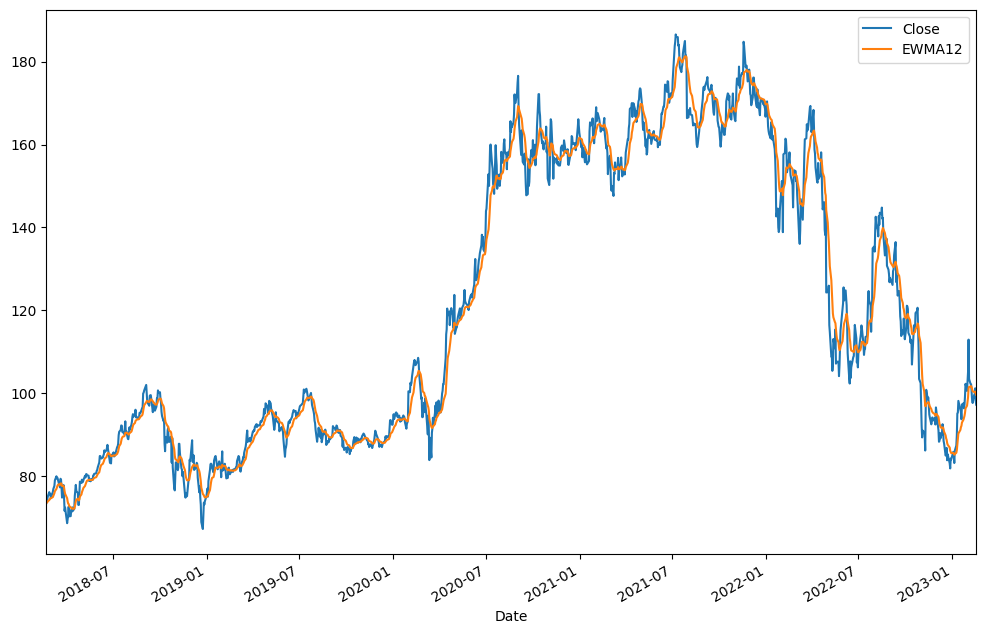

In [ ]:
df1['EWMA12'] = df1['Close'].ewm(span=12,adjust=False).mean()
# Alpha value is calculated based on time interval (span)
# span = 12, alpha = 2/(span+1)
df1[['Close','EWMA12']].plot(figsize=(12,8)).autoscale(axis='x',tight=True);

In [ ]:
# Split data into training and testing data

# all but last 12 months as training data
train_data = df1.iloc[:-12]
# Last 12 Months as Test Data
test_data = df1.iloc[-12:]

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
model = ExponentialSmoothing(train_data['Close'],
                              trend='add',
                              seasonal='mul',
                              seasonal_periods=12)
fitted_model = model.fit()

In [ ]:
fitted_model.summary()

Dep. Variable:,Close,No. Observations:,1247
Model:,ExponentialSmoothing,SSE,9336.076
Optimized:,True,AIC,2542.392
Trend:,Additive,BIC,2624.448
Seasonal:,Multiplicative,AICC,2542.949
Seasonal Periods:,12,Date:,"Tue, 08 Apr 2025"
Box-Cox:,False,Time:,00:03:11
Box-Cox Coeff.:,None,,
,coeff,code,optimized
smoothing_level,0.9841381,alpha,True
smoothing_trend,1.5345e-10,beta,True


In [ ]:
# Forecast for 24 months ≈ 730 calendar days
forecast = best_model.get_forecast(steps=730)
forecast_mean = forecast.predicted_mean
conf_int = forecast.conf_int()
last_date = df1.index[-1]
forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=730, freq='D')

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
# Split real data into train/test (last 24 for test)
test_size = 24
train_data = df1[:-test_size]
test_data = df1[-test_size:]

#  ARIMA on training data
best_model = ARIMA(train_data['Close'], order=best_order).fit()

# Forecast same number of steps as test data
forecast = best_model.get_forecast(steps=test_size)
forecast_mean = forecast.predicted_mean

#  Evaluate performance
arima_true = test_data['Close'].values
arima_pred = forecast_mean.values

mae = mean_absolute_error(arima_true, arima_pred)
rmse = mean_squared_error(arima_true, arima_pred) ** 0.5
mape = mean_absolute_percentage_error(arima_true, arima_pred)

print(" ARIMA Model Performance (on last 24 days):")
print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

 ARIMA Model Performance (on last 24 days):
MAE: 2.9317572981266102
RMSE: 4.215809411920578
MAPE: 0.02851829819942503


ARIMA Model Performance (on last 24 days):
MAE:  2.9318
RMSE: 3.7934
MAPE: 0.0285


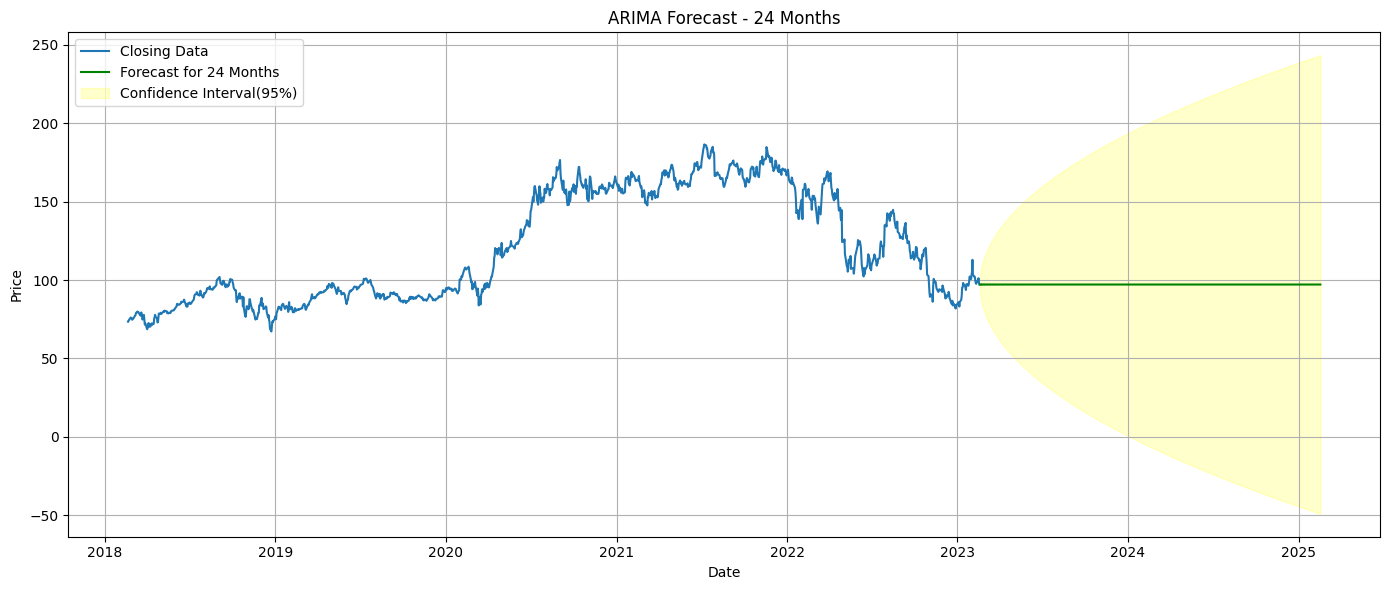

In [ ]:
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt

# Split real data into train/test (last 24 for test)
test_size = 24
train_data = df1[:-test_size]
test_data = df1[-test_size:]

# Train ARIMA model on training data
best_model = ARIMA(train_data['Close'], order=best_order).fit()

# Forecast for test set length
forecast_short = best_model.get_forecast(steps=test_size)
forecast_short_mean = forecast_short.predicted_mean

# Evaluate on test set
arima_true = test_data['Close'].values
arima_pred = forecast_short_mean.values

mae = mean_absolute_error(arima_true, arima_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(arima_true, arima_pred)

print("ARIMA Model Performance (on last 24 days):")
print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAPE: {mape:.4f}")

# ------------------------------------------
# Forecast 24 months (730 calendar days) into the future
# ------------------------------------------
full_model = ARIMA(df1['Close'], order=best_order).fit()
forecast_long = full_model.get_forecast(steps=730)
forecast_mean = forecast_long.predicted_mean
conf_int = forecast_long.conf_int()

# Create future date index
last_date = df1.index[-1]
forecast_index = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=730, freq='D')

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'Forecast': forecast_mean.values,
    'Lower CI': conf_int.iloc[:, 0].values,
    'Upper CI': conf_int.iloc[:, 1].values
}, index=forecast_index)

# ------------------------------------------
# Plot full forecast
# ------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(df1['Close'], label='Closing Data')
plt.plot(forecast_df['Forecast'], label='Forecast for 24 Months', color='green')
plt.fill_between(forecast_df.index, forecast_df['Lower CI'], forecast_df['Upper CI'],
                 color='yellow', alpha=0.2, label='Confidence Interval(95%)')
plt.title("ARIMA Forecast - 24 Months")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()
